<div class="alert alert-block alert-success">
    <h1 align="center">XGBoost (TimeSeries) - Energy Consumption</h1>
    <h3 align="center">Supervised Time Series Regression</h3>
    
<a href="https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption">
Click for more information for dataset
    </a>
</div>


<img src="https://terrapass.com/wp-content/uploads/2022/01/world-energy-consumption-gas-house-emissions-from-power-plant.jpg" />



<div style="
    background-color:#e6f9e6;
    border-left:6px solid #4caf50;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:10px;">
        Welcome to this Notebook...! 
    </p>
    <p style="margin-bottom:10px; text-align:justify;">
        This notebook focuses on forecasting future electricity demand using the PJM hourly energy consumption data and an XGBoost regression model.
    </p>
</div>


<div style="
    background-color:#e6f9e6;
    border-left:6px solid #4caf50;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="margin-bottom:10px;text-align:justify;">
The PJME_hourly.csv dataset contains hourly electricity consumption data (in megawatts) for the PJM East (PJME) region from approximately 2002 to 2018. It is a clean, single-column time series (Datetime index + PJME_MW) widely used for short-term load forecasting and time series modeling.
    </p>
</div>

<div style="
    background-color:#e6f9e6;
    border-left:6px solid #4caf50;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="margin-bottom:10px;text-align:justify;">
Energy consumption time series often show clear seasonal patterns rather than random or linear behavior.
These repeating cycles reflect regular usage habits across hours, days, and seasons, making seasonality a key characteristic of this dataset.
    </p>
</div>

<img src="https://miro.medium.com/max/1400/1*V_RKPeIxCB9CS_2SsLyKXw.jpeg" />

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        1. Load Libraries + Dataset
    </p>
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#---
from statsmodels.tsa.seasonal import seasonal_decompose
#--- 
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
#---
from xgboost import XGBRegressor
#---
plt.style.use('grayscale')
color_pal = sns.color_palette()
plt.style.use('petroff10')
#---
import warnings
warnings.filterwarnings('ignore')
#---
data = pd.read_csv('PJME_hourly.csv')

In [3]:
class color:
    BLUE = '\033[94m'
    GREEN = '\033[32m'
    BRIGHT_GREEN = '\033[92m'
    YELLOW = '\033[33m'
    BRIGHT_YELLOW = '\033[93m'
    RED = '\033[31m'
    BRIGHT_RED = '\033[91m'
    BOLD = '\033[1m'
    UNDERLINE = '\033[4m'
    BROWN = '\033[33m'
    DARK_BROWN = '\033[1;33m'
    END = '\033[0m'

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        1-1. Data Overview
    </p>
</div>

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  object 
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB


In [5]:
data.describe().style.\
set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#006600'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'left'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('padding', '8px')]}
    ]) \
    .set_properties(**{'font-size': '14px', 'background-color': 'white', 'border-collapse': 'collapse', 'margin': '10px'})

,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


In [6]:
print(f'{color.DARK_BROWN}Data Duplicated: {data.duplicated().sum()}')
print(f'{color.DARK_BROWN}Missing: {data.isna().sum()}')

Data Duplicated: 0
Missing: Datetime    0
PJME_MW     0
dtype: int64


In [7]:
data.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [8]:
data.tail()

,Datetime,PJME_MW
145361,2018-01-01 20:00:00,44284.0
145362,2018-01-01 21:00:00,43751.0
145363,2018-01-01 22:00:00,42402.0
145364,2018-01-01 23:00:00,40164.0
145365,2018-01-02 00:00:00,38608.0


<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:10px;">
        Description:
    </p>
    <ul style="margin:0;padding-left:20px; text-align:justify;">
        <li>
The data spans from the last month of 2002 to the beginning of 2018 and is recorded at hourly intervals.  
        </li>
        <li>
There are no missing values in the dataset.  
        </li>
        <li>
The datetime column is currently stored as an object type, which will be properly converted to datetime in the next steps.
        </li>
    </ul>
</div>

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        2. Exploratory Data Analysis + Data Cleaning
    </p>
</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li>
        Convert Datetime Column:
         </li>
        </ul>
</div>





In [9]:
data = data.set_index(pd.to_datetime(data.Datetime))
data.drop(columns='Datetime', inplace=True)

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li>
        Full Hourly PJME Consumption – 2002 to 2018:
         </li>
        </ul>
</div>

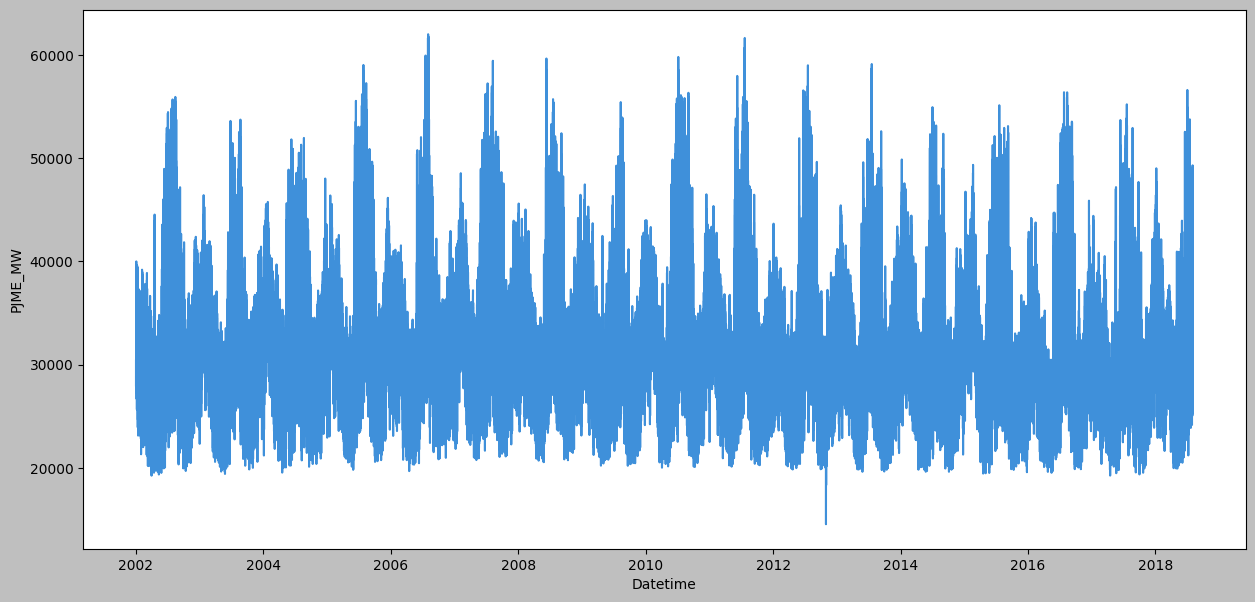

In [10]:
plt.figure(figsize=(15,7))
sns.lineplot(y= data.PJME_MW, x=data.index)
plt.show()

<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:10px;">
        Description:
    </p>
    <ul style="margin:0;padding-left:20px; text-align:justify;">
        <li>
The figure shows hourly electricity consumption over time, where clear and recurring seasonal patterns are evident. Regular peaks and dips correspond to daily and weekly demand cycles driven by human activity, operational schedules, and external factors such as weather. This pronounced seasonality is a fundamental characteristic of consumption-based time series and plays a key role in forecasting future energy demand.
        </li>
    </ul>
</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li>
       Weekly Electricity Consumption Pattern:
         </li>
        </ul>
</div>

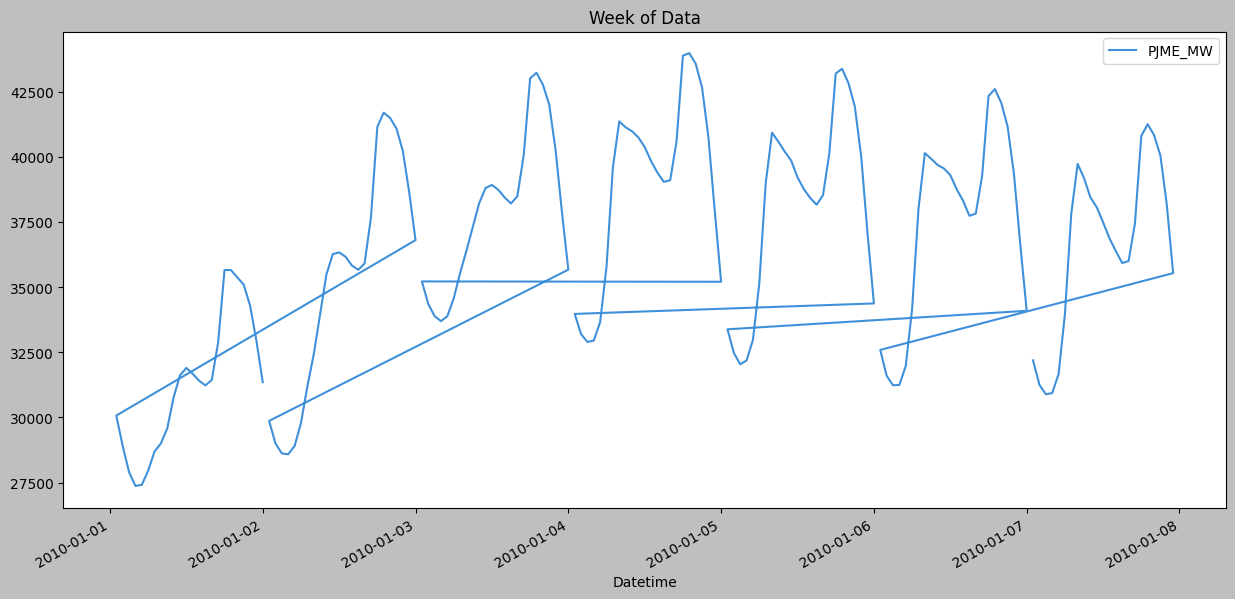

In [11]:
data[(data.index > '2010-01-01') & (data.index < '2010-01-08')].plot(figsize=(15,7), title='Week of Data')
plt.show()

<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:10px;">
        Description:
    </p>
    <ul style="margin:0;padding-left:20px; text-align:justify;">
        <li>
This one-week snapshot of the PJM energy consumption data clearly highlights the strong intraday and daily seasonal structure of electricity demand. Each day follows a consistent cycle with lower consumption during nighttime hours and pronounced peaks during active daytime periods. The repetition of this pattern across consecutive days reflects stable behavioral and operational rhythms, reinforcing the importance of capturing short-term seasonality in forecasting models.
        </li>
    </ul>
</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li>
       Seasonal Decomposition of PJME Hourly Consumption
         </li>
        </ul>
</div>

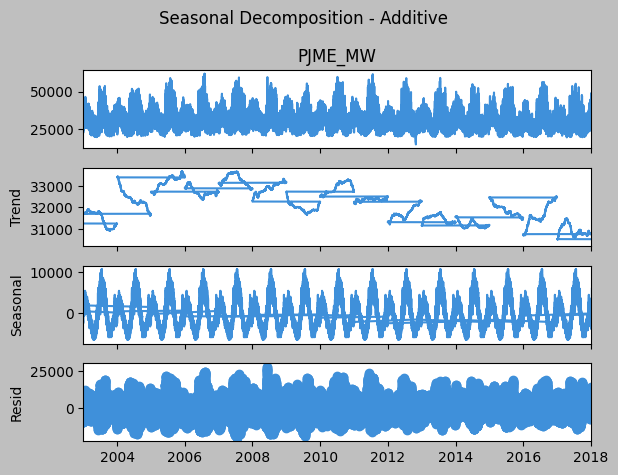

In [12]:
decomp = seasonal_decompose(data['PJME_MW'], model='additive', period=24*365)

decomp.plot()
plt.suptitle('Seasonal Decomposition - Additive')
plt.tight_layout()
plt.show()

<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:10px;">
        Description:
    </p>
    <ul style="margin:0;padding-left:20px; text-align:justify;">
        <li>
Trend: slow long-term movement in average consumption
        </li>
        <li>
Seasonal: prominent yearly cycle with higher demand in summer and winter
        </li>
        <li>
Residual: remaining irregular variations after removing trend and seasonality
        </li>
    </ul>
</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <p style="font-weight:bold;margin-bottom:10px;">
         Simple Temporal Train/Test Split:
    </p>
           <p style="margin-bottom:10px; text-align: justify;">
         In time series forecasting, we cannot use a traditional random split because the chronological order of data points is crucial. Shuffling the data would lead to "data leakage," where the model inadvertently learns from future information to predict the past.
    </p>
           <p style="margin-bottom:10px;">
Instead, we use a fixed-point temporal split:
    </p>
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li>
   Training Set: All data points prior to a specific cutoff date (e.g., 2015-01-01).   
         </li>
                <li>
Test Set: All data points from that date forward.
         </li>
        </ul><br />
                   <p style="margin-bottom:10px; text-align: justify;">
This approach simulates a real-world scenario where the model is trained on historical patterns to forecast "unseen" future consumption.
</div>


In [13]:
X_train = data.loc[data.index < '2015-01-01']
X_test =  data.loc[data.index >= '2015-01-01']

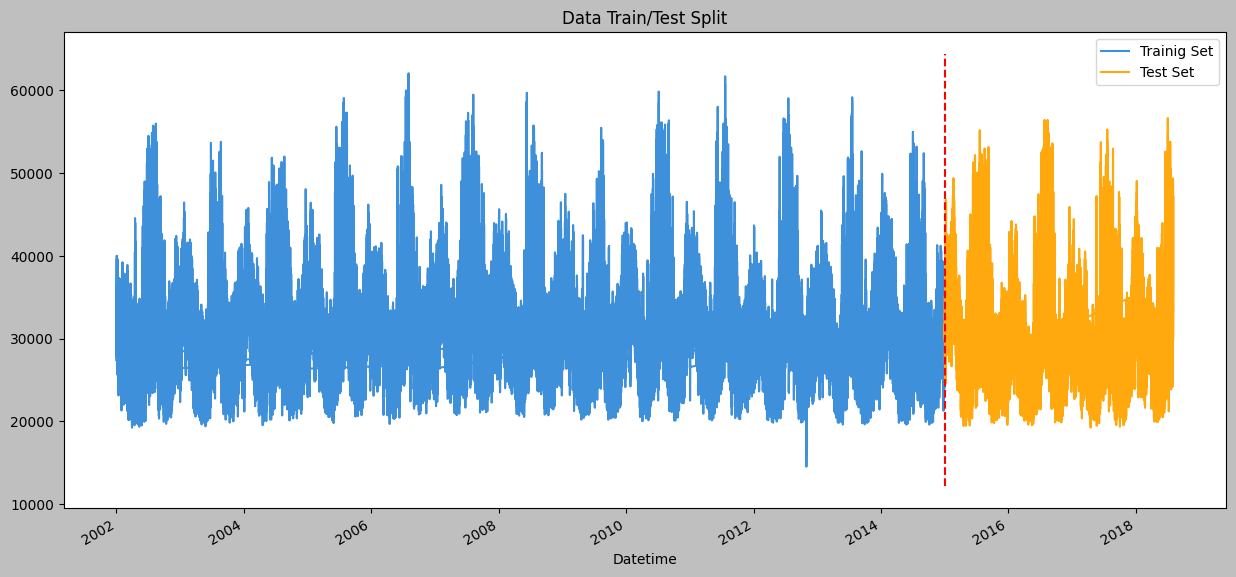

In [14]:
fig, ax = plt.subplots(figsize=(15,7))
X_train.plot(ax=ax,label='Training Set',  title='Data Train/Test Split')
X_test.plot(ax=ax, label='Test Set')

y_min, y_max = ax.get_ylim()

ax.vlines(x='2015-01-01', color ='red', ls='--', ymin=y_min,ymax=y_max)
ax.legend(['Trainig Set','Test Set'])
plt.show()

<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <ul style="margin:0;padding-left:20px; text-align:justify;">
        <li>
While this simple split provides a good baseline, it only evaluates our model on a single window of time. To ensure our model's robustness across different periods and seasonal cycles, we will later implement Time Series Cross-Validation (specifically TimeSeriesSplit). This "Rolling Window" approach will allow us to validate the model on multiple folds without violating the temporal order of the data.
        </li>
    </ul>
</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li>
       Time series Cross Validation
         </li>
        </ul>
</div>

In [15]:
tss= TimeSeriesSplit(n_splits=5, test_size=24*365*1, gap=24)
data = data.sort_index()

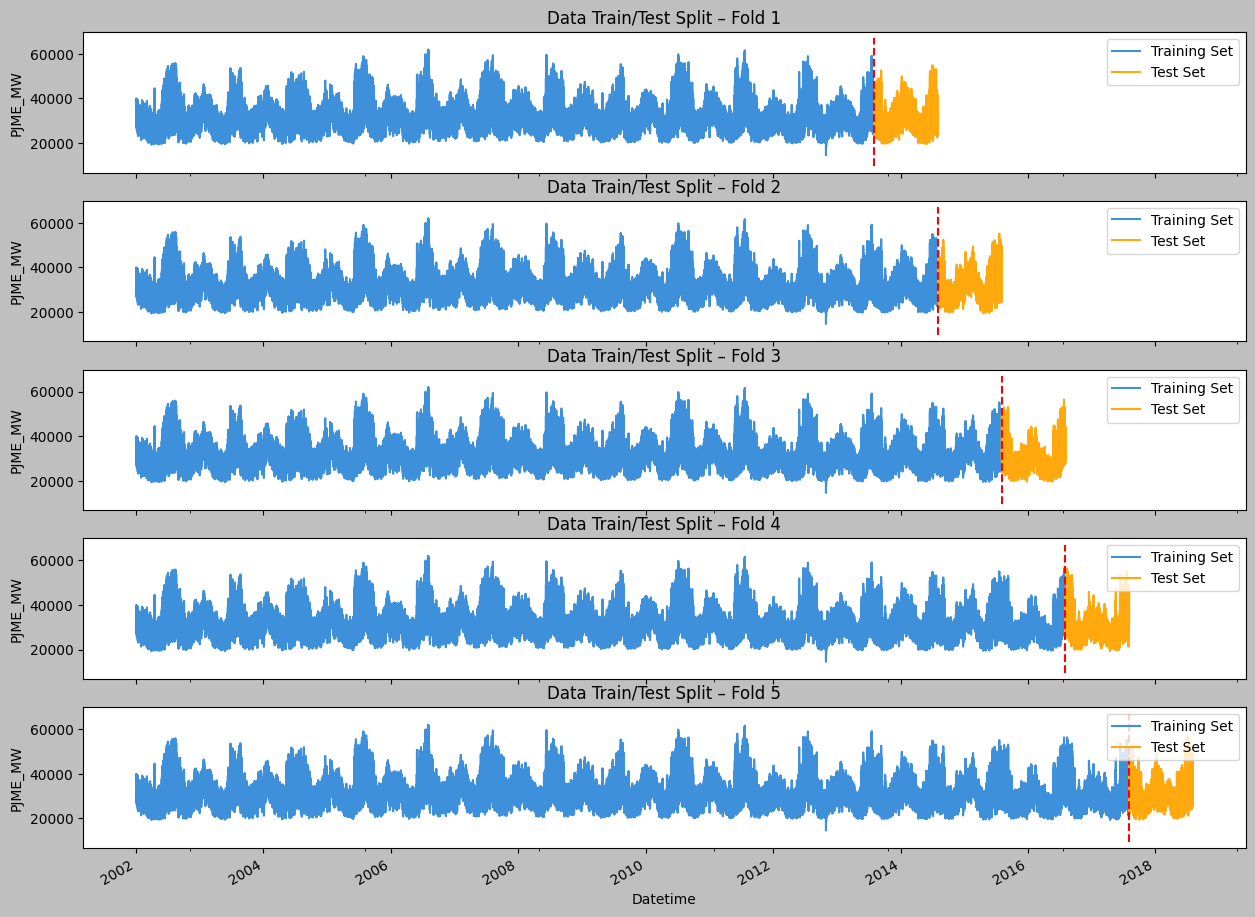

In [16]:
fig, axs = plt.subplots(5, 1, figsize=(15, 12), sharex=True)


for fold,  (train_idx, test_idx) in enumerate(tss.split(data)):
    train = data.iloc[train_idx]
    test = data.iloc[test_idx]
    train.PJME_MW.plot(ax=axs[fold], title=f'Data Train/Test Split{fold}', label='Training Set')
    test.PJME_MW.plot(ax=axs[fold], label='Test Set')
    y_min, y_max = ax.get_ylim()

    axs[fold].vlines(test.index.min(), color ='red', ls='--', ymin=y_min,ymax=y_max)

    axs[fold].set_title(f'Data Train/Test Split – Fold {fold+1}')
    axs[fold].set_ylabel('PJME_MW')
    axs[fold].legend(loc='upper right')
plt.show()

<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:10px;">
        Description:
    </p>
    <ul style="margin:0;padding-left:20px; text-align:justify;">
        <li>
The figure shows the 5-fold TimeSeriesSplit used for model evaluation on the PJME hourly dataset. Each fold maintains chronological order: training data covers earlier periods, while the test set is always the subsequent unseen period (orange section after the red dashed line). This approach prevents data leakage and simulates real-world forecasting by ensuring the model is evaluated only on future data relative to the training window.
        </li>
    </ul>
</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li>
       Feature Creation:
         </li>
        </ul>
</div>

In [17]:
#Create time series features based on time series index.
def create_features(df):

    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

df = create_features(data)

In [18]:
df.sample(5)

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
Datetime,,,,,,,,,
2006-08-02 19:00:00,60286.0,19,2,3,8,2006,214,2,31
2014-05-05 02:00:00,21129.0,2,0,2,5,2014,125,5,19
2012-12-22 12:00:00,33450.0,12,5,4,12,2012,357,22,51
2008-10-25 06:00:00,23169.0,6,5,4,10,2008,299,25,43
2010-03-26 19:00:00,31121.0,19,4,1,3,2010,85,26,12


In [19]:
#Create Lag Features
def add_lag (df):
    df = df.copy()
    target_map = df['PJME_MW'].to_dict()
    df['lag_7d'] = (df.index - pd.Timedelta('7 days')).map(target_map)
    df['lag_28d'] = (df.index - pd.Timedelta('28 days')).map(target_map)
    df['lag_1y'] = (df.index - pd.Timedelta('364 days')).map(target_map)
    df['lag_2y'] = (df.index - pd.Timedelta('728 days')).map(target_map)
    df['lag_3y'] = (df.index - pd.Timedelta('1092 days')).map(target_map)
    return df
df = add_lag(df)

In [20]:
df.tail(5)

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,lag_7d,lag_28d,lag_1y,lag_2y,lag_3y
Datetime,,,,,,,,,,,,,,
2018-08-02 20:00:00,44057.0,20,3,3,8,2018,214,2,31,46337.0,50066.0,42256.0,41485.0,38804.0
2018-08-02 21:00:00,43256.0,21,3,3,8,2018,214,2,31,44542.0,48431.0,41210.0,40249.0,38748.0
2018-08-02 22:00:00,41552.0,22,3,3,8,2018,214,2,31,42638.0,46736.0,39525.0,38698.0,37330.0
2018-08-02 23:00:00,38500.0,23,3,3,8,2018,214,2,31,39276.0,43432.0,36490.0,35406.0,34552.0
2018-08-03 00:00:00,35486.0,0,4,3,8,2018,215,3,31,35742.0,40087.0,33539.0,32094.0,31695.0


<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:10px;">
        Description:
    </p>
    <ul style="margin:0;padding-left:20px; text-align:justify;">
        <li>
To enhance the XGBoost model's ability to capture temporal patterns in hourly electricity consumption, a set of calendar-based and lagged features was engineered. Calendar features include hour of the day, day of the week, quarter, month, year, day of the year, day of the month, and ISO week of the year — these help the model understand recurring daily, weekly, monthly, and yearly seasonality. Lag features capture historical autocorrelation by including consumption values from exactly 7 days, 28 days, 1 year (364 days), 2 years (728 days), and 3 years (1092 days) earlier, allowing the model to learn from similar periods in the past (e.g., same day last week, same season last year). Together, these features provide rich context about time-of-day effects, weekly routines, and long-term seasonal cycles typical in energy load data.
        </li>
    </ul>
</div>




<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li>
       Visualize our Feature / Target Relationship:
         </li>
        </ul>
</div>

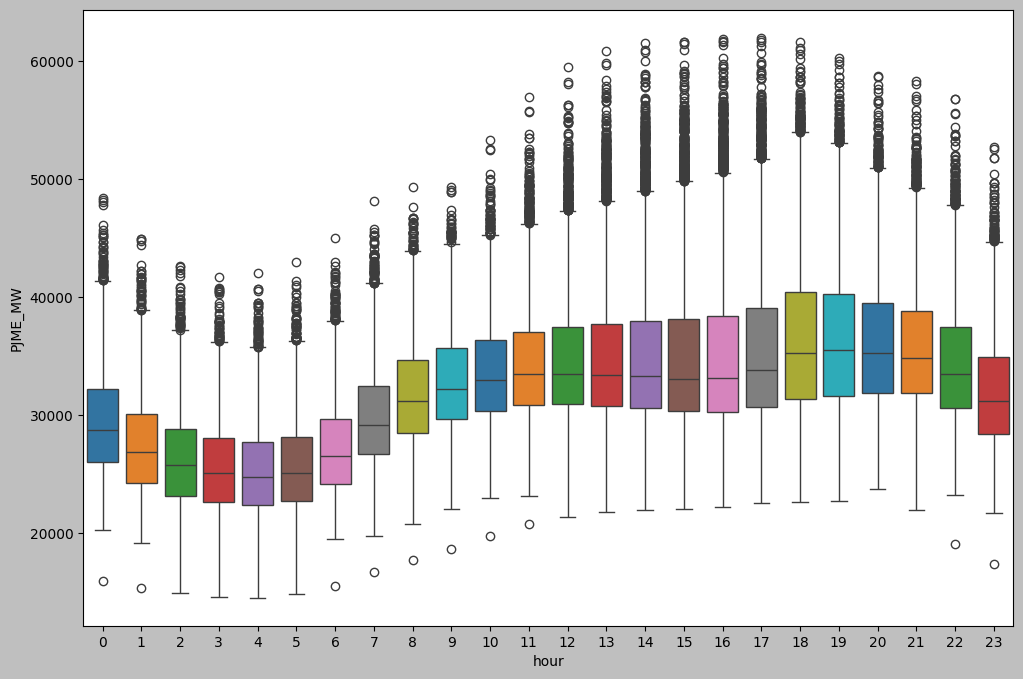

In [21]:
#Daily Energy Consumption Pattern
plt.figure(figsize=(12,8))
sns.boxplot(df, x='hour', y='PJME_MW', palette='tab10')
plt.show()

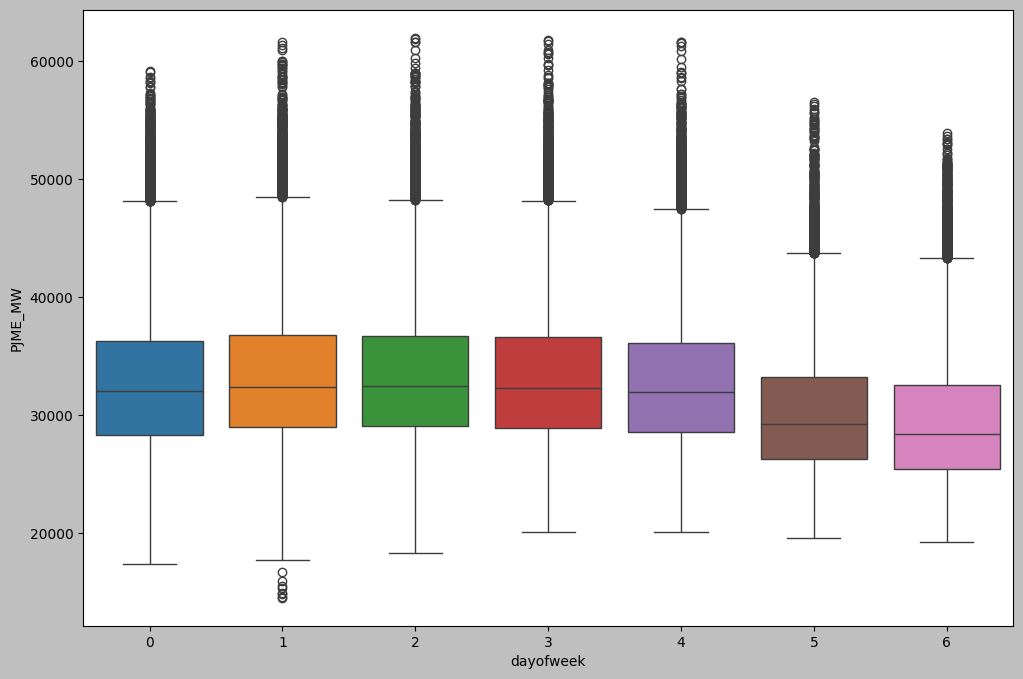

In [22]:
#Weekly Energy Consumption Pattern
plt.figure(figsize=(12,8))
sns.boxplot(df, x='dayofweek', y='PJME_MW', palette='tab10')
plt.show()

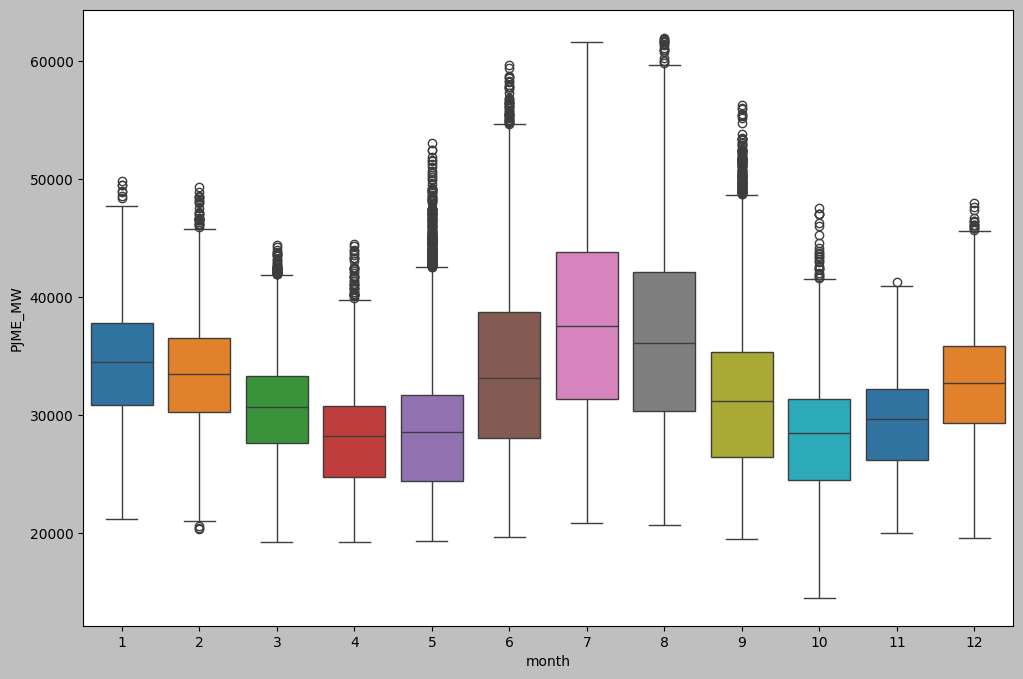

In [23]:
#Monthly Energy Consumption Pattern
plt.figure(figsize=(12,8))
sns.boxplot(df, x='month', y='PJME_MW', palette='tab10')
plt.show()

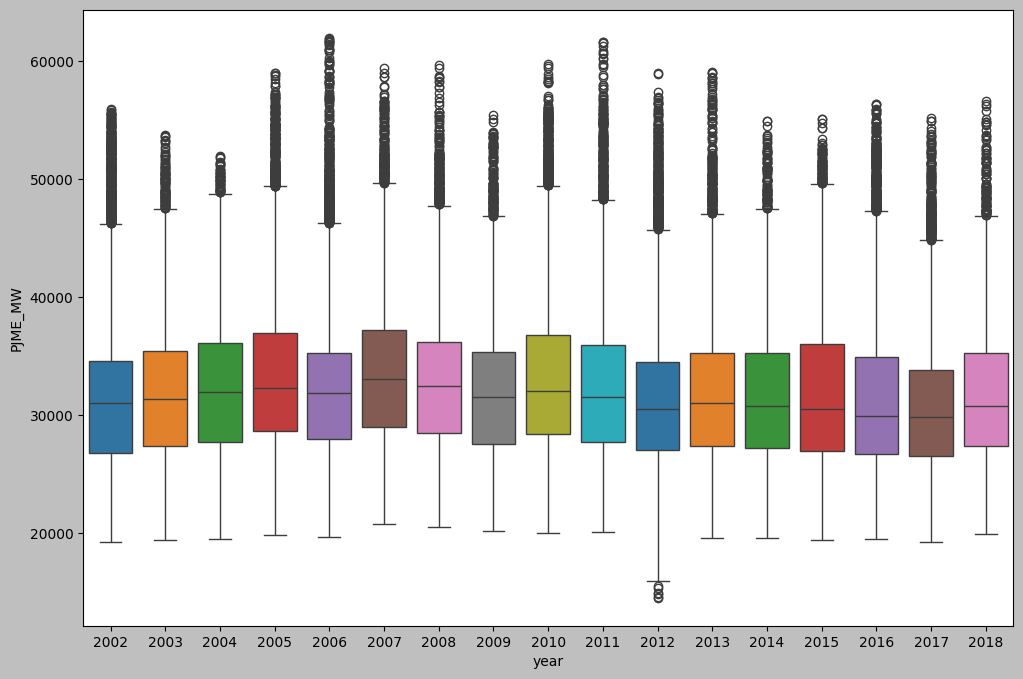

In [24]:
#Yearly Energy Consumption Pattern
plt.figure(figsize=(12,8))
sns.boxplot(df, x='year', y='PJME_MW', palette='tab10')
plt.show()

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        3. Modeling
    </p>
</div>

In [25]:
cols=['hour', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear',
       'dayofmonth', 'weekofyear', 'lag_7d', 'lag_28d', 'lag_1y', 'lag_2y','lag_3y']
scores = []
preds = []
for train_idx, test_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[test_idx]

    X_train = train[cols]
    y_train = train['PJME_MW']
    #---
    X_test = test[cols]
    y_test = test['PJME_MW']

    model = XGBRegressor(n_estimators=1000,
                           early_stopping_rounds=50,
                           max_depth=3,
                           learning_rate=0.01)

    model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)],
            verbose=100)

    y_pred = model.predict(X_test)
    preds.append(y_pred)
    score = np.sqrt(mean_squared_error(y_test, y_pred))
    scores.append(score)

[0]	validation_0-rmse:6455.75591	validation_1-rmse:6141.95846
[100]	validation_0-rmse:4132.64535	validation_1-rmse:4009.94773
[200]	validation_0-rmse:3497.09989	validation_1-rmse:3599.08508
[300]	validation_0-rmse:3292.62224	validation_1-rmse:3562.31833
[350]	validation_0-rmse:3244.36829	validation_1-rmse:3567.09543
[0]	validation_0-rmse:6431.23211	validation_1-rmse:6249.48627
[100]	validation_0-rmse:4134.34578	validation_1-rmse:4102.02340
[200]	validation_0-rmse:3515.11692	validation_1-rmse:3586.47010
[300]	validation_0-rmse:3321.52482	validation_1-rmse:3464.22495
[400]	validation_0-rmse:3239.96593	validation_1-rmse:3420.32033
[500]	validation_0-rmse:3186.98745	validation_1-rmse:3396.33956
[600]	validation_0-rmse:3151.35453	validation_1-rmse:3383.82074
[700]	validation_0-rmse:3125.41923	validation_1-rmse:3376.64128
[800]	validation_0-rmse:3102.19399	validation_1-rmse:3367.24912
[900]	validation_0-rmse:3082.11140	validation_1-rmse:3365.73250
[0]	validation_0-rmse:6416.68034	validation_

In [26]:
print(f'Score across folds {np.mean(scores):0.2f}')
print(f'Fold scores:{scores}')

Score across folds 3558.49
Fold scores:[np.float64(3562.3183316573404), np.float64(3364.2898835822502), np.float64(3259.5094254386454), np.float64(3860.3266393080517), np.float64(3745.981500193734)]


<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:10px;">
        Description: Model Training & Cross-Validation Results
    </p>
    <ul style="margin:0;padding-left:20px; text-align:justify;">
        <li>
            The XGBoost model was trained using time-series cross-validation (TimeSeriesSplit) with carefully engineered calendar and lag features.
The average RMSE across all folds is 3558.49 MW, with fold scores ranging from ~3259 to 3860 MW — indicating reasonable and consistent performance for hourly energy forecasting.In the next part, we will fit the model on the entire dataset and generate forecasts for the next full year (one year ahead).
        </li>
    </ul>
</div>




<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li>
       Fitting the Model to All Data:
         </li>
        </ul>
</div>

In [27]:
X_all = df.drop(columns='PJME_MW')
y_all = df.PJME_MW

final_model = XGBRegressor(base_score=0.5,
                   booster='gbtree',    
                   n_estimators=1000,
                   objective='reg:linear',
                   max_depth=3,
                   learning_rate=0.01)

final_model.fit(X_all, y_all, eval_set=[(X_all, y_all)], verbose=100)

[0]	validation_0-rmse:32402.07379
[100]	validation_0-rmse:12352.64008
[200]	validation_0-rmse:5555.88739
[300]	validation_0-rmse:3730.63048
[400]	validation_0-rmse:3365.56361
[500]	validation_0-rmse:3277.14068
[600]	validation_0-rmse:3241.34546
[700]	validation_0-rmse:3216.72869
[800]	validation_0-rmse:3196.84832
[900]	validation_0-rmse:3177.98591
[999]	validation_0-rmse:3161.62079


,objective,'reg:linear'
,base_score,0.5
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li>
       Create Feature:
         </li>
        </ul>
</div>

In [28]:
#Last Record:
df.index.max()

Timestamp('2018-08-03 00:00:00')

In [29]:
#Create Feature:
future = pd.date_range('2018-08-04','2019-08-01', freq='1h')
future_df = pd.DataFrame(index=future)
future_df['isFuture'] = True
df['isFuture'] = False
df_and_future = pd.concat([df, future_df])
df_and_future = create_features(df_and_future)
df_and_future = add_lag(df_and_future)
#---
#Separating future values
future_w_features = df_and_future.query('isFuture').copy()

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li>
       Making Predictions - 2019:
         </li>
        </ul>
</div>

In [30]:
test_data = future_w_features.drop(columns=['PJME_MW','isFuture'])
future_w_features['pred'] = final_model.predict(test_data)

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li>
       Plotting Prediction - 2019:
         </li>
        </ul>
</div>

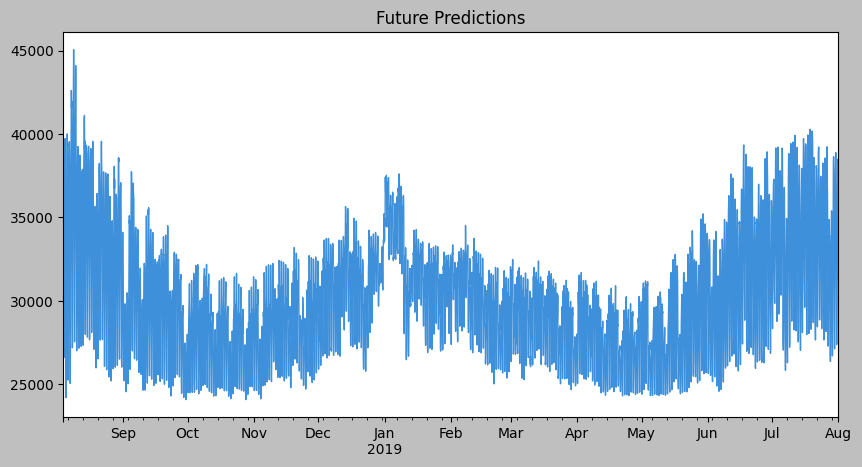

In [35]:
future_w_features['pred'].plot(figsize=(10, 5), ms=1, lw=1, title='Future Predictions')
plt.show()

<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:10px;">
        Description:
    </p>
    <ul style="margin:0;padding-left:20px; text-align:justify;">
        <li>

The plot shows the model's one-year-ahead predictions for PJME hourly electricity consumption throughout 2019, generated after retraining on the full historical dataset (2002–2018).
        </li>
                <li>
The forecasts successfully capture the expected seasonal patterns, including higher demand in summer (cooling) and winter (heating), as well as regular daily and weekly cycles, demonstrating good generalization to unseen future data.
        </li>
    </ul>
</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li>
       Feature Importance:
         </li>
        </ul>
</div>

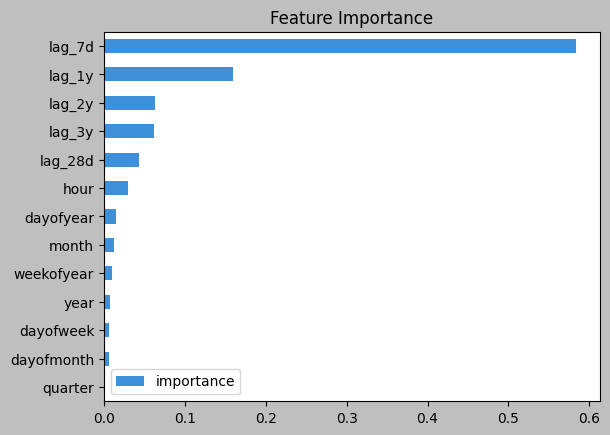

In [38]:
fi = pd.DataFrame(data=final_model.feature_importances_,
             index=final_model.feature_names_in_,
             columns=['importance'])
fi.sort_values('importance').plot(kind='barh', title='Feature Importance')
plt.show()

<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:10px;">
        Description:
    </p>
    <ul style="margin:0;padding-left:20px; text-align:justify;">
        <li>
Lag features dominate significantly, with lag_7d (previous week same hour) being by far the most important (≈0.58), followed by lag_1y (same day last year). This highlights how strongly the model relies on recent weekly and annual historical patterns for accurate hourly forecasting. Calendar features (hour, dayofyear, month, etc.) contribute much less in comparison.
        </li>
    </ul>
</div>

<div
    style="
        background-color:#e6f9e6;
        border-left:6px solid #4caf50;
        padding: 20px;
        border-radius: 8px;
        margin: 20px 0;
        font-size: 16px;
        line-height: 1.6;
    "
>
    <h2 style="text-align: center; color: #4caf50; margin-top: 0;">
        Project Summary - Key Highlights
    </h2>
    <ul style="padding-left: 25px; text-align: justify;">
        <li>
Data Exploration & Initial Analysis: Loaded and cleaned the PJME hourly electricity consumption dataset (2002–2018). Visualized the full time series and confirmed strong multi-scale seasonality (daily, weekly, yearly cycles) via line plots and decomposition.
        </li>
        <li>

Seasonal Decomposition: Applied additive seasonal decomposition (statsmodels) to clearly separate trend, seasonal (prominent yearly pattern with daily/weekly hints), and residual components — confirming the highly seasonal nature of energy load data.
        </li>
        <li>
Feature Engineering: Created calendar-based features: hour, dayofweek, month, quarter, year, dayofyear, etc.
Added powerful lag features: 7-day, 28-day, 1-year, 2-year, and 3-year lags to capture autocorrelation at different horizons.
        </li>
        <li>
Model Training & Cross-Validation: Trained XGBoost regressor using TimeSeriesSplit cross-validation.
Achieved average RMSE ≈ 3558 MW across folds — reasonable performance for hourly forecasting with the selected features.
        </li>
        <li>
Feature Importance Analysis: Lag features (especially lag_7d and lag_1y) dominated importance scores, showing the model heavily relies on recent weekly and annual historical patterns. Calendar features played a secondary but supportive role.
        </li>
        <li>
Final Model Training & Future Forecasting: Retrained the model on the entire historical dataset (2002–2018).
Generated one-year-ahead forecasts (2019) to evaluate real-world generalization and capture expected future behavioral patterns.
        </li>
    </ul>
    </p>
</div>